# Temp-Controlled RAPL Analysis

This notebook explores the run-level summary in `temp_controlled_runs.csv` and one or more per-ms traces from `temp_controlled_samples/`.

The sample files contain repeated rows for each metric, so the notebook reshapes them into a simple time series before plotting.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

base_dir = Path("logs/temp_controlled_logs")
runs_path = base_dir / "temp_controlled_runs.csv"
sample_dir = base_dir / "temp_controlled_samples"

runs = pd.read_csv(runs_path)
runs["timestamp_utc"] = pd.to_datetime(runs["timestamp_utc"], utc=True, errors="coerce")
runs = runs.sort_values(["query_filter", "loop_index", "timestamp_utc"])

print(f"Runs: {runs.shape[0]} rows, {runs.shape[1]} columns")
display(runs.head())
display(runs.dtypes.to_frame("dtype"))

Runs: 242 rows, 22 columns


,timestamp_utc,run_id,test_name,loop_index,loops,runs_per_loop,total_runs,total_elapsed_sec,failures,rapl_package_j,...,rapl_dram_j,start_pkg_tmp_c,end_pkg_tmp_c,cooldown_wait_sec,cooldown_threshold_c,rapl_1ms_file,query_dir,query_filter,sigless_addr,run_started_utc
0,2026-04-20 11:33:36+00:00,2FFFF73F79C292CE,APX1145-queryA.sql,1,1,1,1,1.583717,0,35.887817,...,NaN,32.0,35.0,16.053275,40.0,logs/temp_controlled_samples/2FFFF73F79C292CE_...,queries,APX1145,127.0.0.1:8000,2026-04-20T11:33:15Z
1,2026-04-20 11:33:39+00:00,2FFFF73F79C292CE,APX1145-queryB.sql,1,1,1,1,0.492680,0,11.303772,...,NaN,33.0,34.0,0.000000,40.0,logs/temp_controlled_samples/2FFFF73F79C292CE_...,queries,APX1145,127.0.0.1:8000,2026-04-20T11:33:15Z
2,2026-04-20 11:34:38+00:00,1C899B7B2AD1B571,APX1145-queryA.sql,1,10,1,10,0.604760,0,28.885681,...,NaN,34.0,34.0,16.050295,40.0,logs/temp_controlled_samples/1C899B7B2AD1B571_...,queries,APX1145,127.0.0.1:8000,2026-04-20T11:34:18Z
12,2026-04-20 11:37:45+00:00,1C899B7B2AD1B571,APX1145-queryB.sql,1,10,1,10,0.444834,0,25.473145,...,NaN,35.0,36.0,16.049907,40.0,logs/temp_controlled_samples/1C899B7B2AD1B571_...,queries,APX1145,127.0.0.1:8000,2026-04-20T11:34:18Z
3,2026-04-20 11:34:57+00:00,1C899B7B2AD1B571,APX1145-queryA.sql,2,10,1,10,0.599023,0,29.008240,...,NaN,34.0,35.0,16.043072,40.0,logs/temp_controlled_samples/1C899B7B2AD1B571_...,queries,APX1145,127.0.0.1:8000,2026-04-20T11:34:18Z


,dtype
timestamp_utc,"datetime64[ns, UTC]"
run_id,object
test_name,object
loop_index,int64
loops,int64
runs_per_loop,int64
total_runs,int64
total_elapsed_sec,float64
failures,int64
rapl_package_j,float64


## Load and Inspect temp_controlled_samples

In [6]:
sample_files = sorted(sample_dir.glob("*.csv"))
print(f"Sample files: {len(sample_files)}")
display([path.name for path in sample_files[:5]])

sample_columns = [
    "timestamp_sec",
    "joules",
    "unit",
    "metric_path",
    "raw_counter",
    "percent",
    "extra_1",
    "extra_2",
]

def load_sample(path: Path) -> pd.DataFrame:
    raw = pd.read_csv(
        path,
        header=None,
        comment="#",
        names=sample_columns,
        usecols=[0, 1, 2, 3, 4, 5],
    )
    raw["metric"] = raw["metric_path"].str.replace("power/energy-", "", regex=False).str.replace("/", "", regex=False)
    wide = (
        raw.pivot_table(index="timestamp_sec", columns="metric", values="joules", aggfunc="last")
        .reset_index()
        .sort_values("timestamp_sec")
    )
    return wide

first_sample = load_sample(sample_files[0]) if sample_files else pd.DataFrame()
print("First sample file:", sample_files[0].name if sample_files else "none")
display(first_sample.head())
display(pd.DataFrame({"column": first_sample.columns}) if not first_sample.empty else pd.DataFrame())

Sample files: 242


['1C899B7B2AD1B571__APX1145-queryA.sql__loop10_run1.rapl.csv',
 '1C899B7B2AD1B571__APX1145-queryA.sql__loop1_run1.rapl.csv',
 '1C899B7B2AD1B571__APX1145-queryA.sql__loop2_run1.rapl.csv',
 '1C899B7B2AD1B571__APX1145-queryA.sql__loop3_run1.rapl.csv',
 '1C899B7B2AD1B571__APX1145-queryA.sql__loop4_run1.rapl.csv']

First sample file: 1C899B7B2AD1B571__APX1145-queryA.sql__loop10_run1.rapl.csv


metric,timestamp_sec,cores,gpu,pkg,ram
0,0.001103,0.01,0.0,0.01,0.0
1,0.002453,0.01,0.0,0.02,0.0
2,0.003580,0.01,0.0,0.01,0.0
3,0.004705,0.01,0.0,0.01,0.0
4,0.005800,0.01,0.0,0.01,0.0


,column
0,timestamp_sec
1,cores
2,gpu
3,pkg
4,ram


## Grouped Comparison - Absolute Package Energy (runID: 3937CCC4DAFF437B)

Samples for runID 3937CCC4DAFF437B: 220


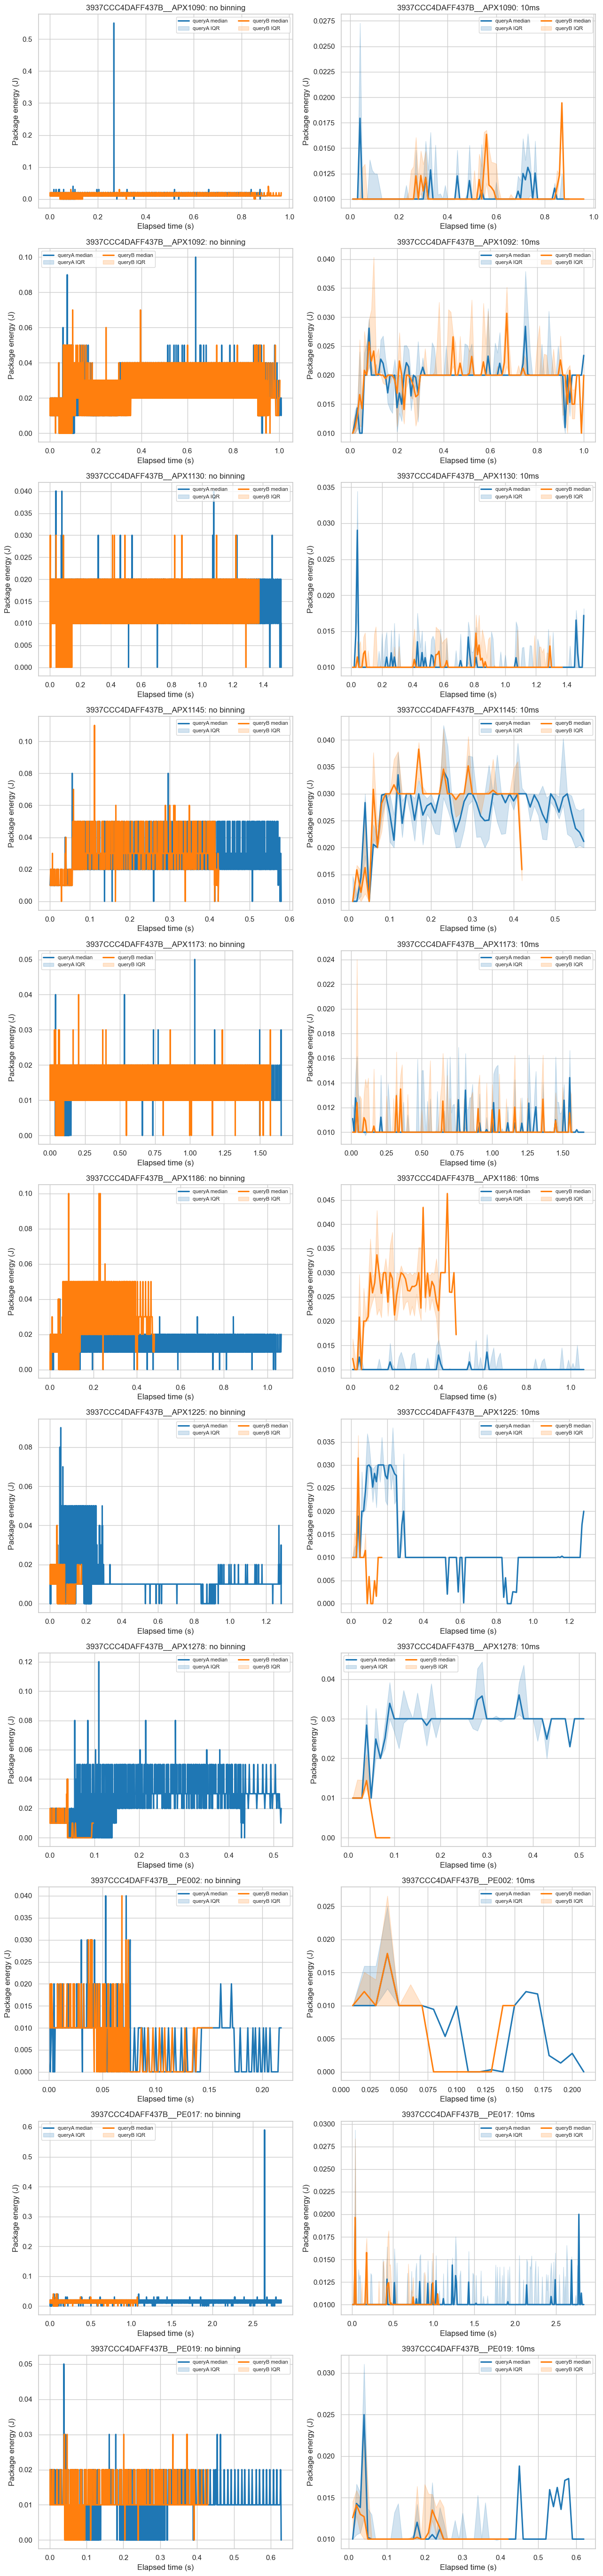

In [9]:
sample_meta = []
for path in sample_files:
    name = path.name
    # Extract runID from filename (assuming format like RUNID__...)
    runid = None
    if "__" in name:
        parts = name.split("__")
        if len(parts) > 0:
            runid = parts[0]
    
    if "queryA" in name:
        variant = "queryA"
    elif "queryB" in name:
        variant = "queryB"
    else:
        variant = None
    
    if variant is not None:
        test_group = name.split("-query", 1)[0] if "-query" in name else None
        if test_group:
            sample_meta.append({
                "path": path, 
                "variant": variant, 
                "test_group": test_group,
                "runid": runid
            })

# Filter by runID
RUNID_FILTER = "3937CCC4DAFF437B"
filtered_meta = [row for row in sample_meta if row.get("runid") == RUNID_FILTER]

print(f"Samples for runID {RUNID_FILTER}: {len(filtered_meta)}")

if not filtered_meta:
    print(f"No samples found for runID {RUNID_FILTER}")
    # Show available runIDs
    available_runids = sorted(set(row.get("runid") for row in sample_meta if row.get("runid")))
    print(f"Available runIDs: {available_runids}")
else:
    sample_groups = sorted({row["test_group"] for row in filtered_meta})
    example_groups = sample_groups
    
    fig, axes = plt.subplots(len(example_groups), 2, figsize=(13, 5 * len(example_groups)), squeeze=False)
    colors = {"queryA": "tab:blue", "queryB": "tab:orange"}

    def absolute_curve(path: Path, grid: np.ndarray) -> pd.DataFrame:
        sample = load_sample(path).copy()
        sample = sample.sort_values("timestamp_sec")
        sample["pkg_j"] = sample["pkg"]

        t = sample["timestamp_sec"].to_numpy()
        y = sample["pkg_j"].to_numpy()
        if len(t) < 2 or (t.max() - t.min()) == 0:
            return pd.DataFrame({"time_sec": grid, "pkg_j": np.nan})

        unique_t, unique_idx = np.unique(t, return_index=True)
        unique_y = y[unique_idx]
        if len(unique_t) < 2:
            return pd.DataFrame({"time_sec": grid, "pkg_j": np.nan})

        y_interp = np.interp(grid, unique_t, unique_y)
        valid = (grid >= unique_t.min()) & (grid <= unique_t.max())
        y_interp = np.where(valid, y_interp, np.nan)
        return pd.DataFrame({"time_sec": grid, "pkg_j": y_interp})

    for row_index, group in enumerate(example_groups):
        group_rows = [row for row in filtered_meta if row["test_group"] == group]

        longest_time = 0.0
        for row in group_rows:
            sample = load_sample(row["path"])
            if not sample.empty:
                longest_time = max(longest_time, float(sample["timestamp_sec"].max()))

        if longest_time <= 0:
            for col_index in range(2):
                axes[row_index, col_index].text(0.5, 0.5, f"{group}: no usable data", ha="center", va="center")
                axes[row_index, col_index].set_axis_off()
            continue

        # Process two binning resolutions: no binning and 10ms
        binning_configs = [(None, "no binning"), (0.010, "10ms")]
        
        for col_index, (bin_size, bin_label) in enumerate(binning_configs):
            if bin_size is None:
                # No binning - use original timestamps from raw data
                curves = []
                for variant in ["queryA", "queryB"]:
                    variant_rows = [row for row in group_rows if row["variant"] == variant][:6]
                    for row in variant_rows:
                        sample = load_sample(row["path"]).copy()
                        sample = sample.sort_values("timestamp_sec")
                        sample = sample[["timestamp_sec", "pkg"]].rename(columns={"timestamp_sec": "time_sec", "pkg": "pkg_j"})
                        sample["variant"] = variant
                        curves.append(sample)
            else:
                # Binned data with specified bin size
                grid = np.arange(0.0, longest_time + bin_size, bin_size)
                curves = []
                for variant in ["queryA", "queryB"]:
                    variant_rows = [row for row in group_rows if row["variant"] == variant][:6]
                    for row in variant_rows:
                        curve = absolute_curve(row["path"], grid)
                        curve["variant"] = variant
                        curves.append(curve)

            if not curves:
                axes[row_index, col_index].text(0.5, 0.5, f"{group}: no curves", ha="center", va="center")
                axes[row_index, col_index].set_axis_off()
                continue

            curves_df = pd.concat(curves, ignore_index=True)
            summary = (
                curves_df.groupby(["variant", "time_sec"])["pkg_j"]
                .agg(
                    median="median",
                    q25=lambda s: s.quantile(0.25),
                    q75=lambda s: s.quantile(0.75),
                )
                .reset_index()
            )

            plot_ax = axes[row_index, col_index]
            for variant in ["queryA", "queryB"]:
                part = summary[summary["variant"] == variant].sort_values("time_sec")
                if part.empty:
                    continue
                plot_ax.plot(
                    part["time_sec"],
                    part["median"],
                    color=colors[variant],
                    linewidth=2.2,
                    label=f"{variant} median",
                )
                plot_ax.fill_between(
                    part["time_sec"],
                    part["q25"],
                    part["q75"],
                    color=colors[variant],
                    alpha=0.20,
                    label=f"{variant} IQR",
                )

            plot_ax.set_title(f"{group}: {bin_label}")
            plot_ax.set_xlabel("Elapsed time (s)")
            plot_ax.set_ylabel("Package energy (J)")
            plot_ax.legend(ncol=2, fontsize=8)

    plt.tight_layout()